# Análise do 99 de Krenko, Mob Boss

Este notebook **não** explica as cartas com lore de Commander nem com EDHREC. Ele reabre a lista em `data/solved_deck.txt` e decompõe o score que o `DeckSolver` realmente usou no fill/cut.

Fórmula v1 (sem teto de orçamento neste demo):

$$\mathrm{score} = 2\cdot\mathrm{synergy} + \mathrm{role\_need} - 1.4\cdot\mathrm{redundancy}$$

- **synergy:** Jaccard de *palavras* (word overlap) entre a carta e `query + texto do commander`. **Não** significa que a carta cria fichas / creature tokens. Se a carta veio do Chroma, o fill usa $\max(\mathrm{Jaccard},\, 1/(1+d))$.
- **role_need:** bônus se o papel (land / ramp / draw / interaction / threat) ainda está abaixo da cota; penalidade se já estourou. `threat` = criatura ou planeswalker no type line, não “é um bom finisher”.
- **redundancy:** maior Jaccard (×1.25 se o papel coincide) contra o resto do 99.

**Como ver por que uma carta entrou:** `insert_rank` + `insert_score` no log, e `chroma_query` (qual busca do retrieval a puxou). O Jaccard pós-hoc é secundário. Cartas dupla-face com `oracle_text` vazio no SQLite foram indexadas no Chroma como *“Vanilla creature / No abilities”* — isso as aproxima do commander só por serem “criaturas”.

**Caveat:** o greedy pontua *no momento da inserção*. Recalcular no 99 fechado subestima cartas que entraram cedo para preencher cota. `data/solved_deck_log.json` guarda a ordem real.

In [20]:
from __future__ import annotations

import json
import os
import re
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from catalog import get_oracle_card
from deck_state import DeckState
from roles import ROLE_QUOTAS, classify_roles, role_counts
from rules_validator import CommanderValidator
from solver import DeckSolver

QUERY = "goblin tokens damage"
COMMANDER = "Krenko, Mob Boss"
LIST_PATH = ROOT / "data" / "solved_deck.txt"
SEED_PATH = ROOT / "data" / "test_deck.txt"
POOL_PATH = ROOT / "data" / "test_pool.txt"
LOG_PATH = ROOT / "data" / "solved_deck_log.json"
ATTACH_CHROMA = True  # False = só Jaccard/papéis, sem carregar MiniLM

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 80)
print("ROOT", ROOT)
print("lista", LIST_PATH, "existe" if LIST_PATH.exists() else "AUSENTE")

ROOT C:\Users\User\Documents\GitHub\ManaGraph
lista C:\Users\User\Documents\GitHub\ManaGraph\data\solved_deck.txt existe


In [21]:
def parse_list(path: Path) -> dict[str, int]:
    pattern = re.compile(r"^(\d+)x?\s+(.+)$")
    cards: dict[str, int] = {}
    with path.open(encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            match = pattern.match(line)
            if not match:
                continue
            name = match.group(2).strip()
            cards[name] = cards.get(name, 0) + int(match.group(1))
    return cards


def origin_of(name: str, commander: str, seed: dict[str, int], pool: dict[str, int], insert_order: dict[str, int]) -> str:
    key = name.lower()
    if commander and key == commander.lower():
        return "commander"
    if key in {n.lower() for n in seed}:
        return "seed (test_deck)"
    if key in {n.lower() for n in pool}:
        return "pool (test_pool)"
    if key in insert_order:
        return "fill greedy"
    return "fill greedy"


def _words(row: pd.Series) -> list[str]:
    raw = row.get("shared_tokens") or []
    if isinstance(raw, str):
        raw = [w.strip() for w in raw.split(",") if w.strip()]
    return [w for w in raw if len(w) > 1 and not str(w).isdigit()]


def why_text(row: pd.Series) -> str:
    bits = []
    origin = row["origin"]
    oracle = (row.get("oracle_text") or "").strip()
    if origin == "commander":
        return "Commander do demo. Não ocupa slot dos 99."
    if origin.startswith("seed"):
        bits.append("Já estava em test_deck.txt; o solver manteve (não foi uma escolha do fill).")
    elif origin.startswith("pool"):
        bits.append("Veio de test_pool.txt e venceu o greedy na hora de preencher.")
    elif pd.notna(row.get("chroma_distance")):
        q = row.get("chroma_query") or "?"
        bits.append(
            f"Entrou no fill porque o Chroma a devolveu na busca «{q}» "
            f"(distância {row['chroma_distance']:.3f} → sinergia geométrica {row['chroma_synergy']:.3f})."
        )
    else:
        bits.append("Candidata do pool/retrieval escolhida pelo fill greedy.")
    if row.get("insert_rank") and pd.notna(row["insert_rank"]):
        bits.append(
            f"Ordem de inserção {int(row['insert_rank'])}/63, score na hora {row.get('insert_score')} "
            "(este é o número que o greedy comparou, não o score pós-hoc)."
        )
    if not oracle and origin == "fill greedy":
        bits.append(
            "Oracle vazio no SQLite (carta com //): o Chroma indexou "
            "«Vanilla creature / No abilities», então a vizinhança com o commander é em grande parte um artefato de ingestão."
        )
    words = _words(row)
    if words:
        bits.append(
            "Overlap de PALAVRAS com query+commander (não são fichas/tokens de criatura): "
            + ", ".join(words[:12])
            + "."
        )
    roles = row.get("roles") or []
    if isinstance(roles, str):
        role_list = [r.strip() for r in roles.split(",") if r.strip()]
    else:
        role_list = list(roles)
    rs = row["role_score"]
    if "threat" in role_list:
        bits.append("Papel threat só porque o type line contém Creature/Planeswalker.")
    if rs >= 2:
        bits.append(f"Neste recálculo o papel {', '.join(role_list)} ainda está abaixo da cota mínima.")
    elif rs < 0:
        bits.append(
            "No 99 fechado a cota desse papel já estourou (penalidade). "
            "Na inserção o bônus era +2.5 (abaixo do mínimo) ou +0.4 (dentro da faixa)."
        )
    if row["redundancy"] >= 0.45 and row.get("redundancy_with"):
        bits.append(f"Redundante com {row['redundancy_with']} ({row['redundancy']:.2f}).")
    bits.append(
        f"Score pós-hoc {row['total']:.3f} = 2×{row['synergy']:.3f} + {row['role_score']:.3f} − 1.4×{row['redundancy']:.3f} "
        "(não use este número para explicar a entrada)."
    )
    return " ".join(bits)

In [22]:
raw = parse_list(LIST_PATH)
seed = parse_list(SEED_PATH) if SEED_PATH.exists() else {}
pool = parse_list(POOL_PATH) if POOL_PATH.exists() else {}
log = json.loads(LOG_PATH.read_text(encoding="utf-8")) if LOG_PATH.exists() else {}
if log.get("query"):
    QUERY = log["query"]

insert_order: dict[str, int] = {}
insert_score: dict[str, float] = {}
for i, item in enumerate(log.get("fill", {}).get("added") or [], start=1):
    name = item["name"]
    key = name.lower()
    insert_order.setdefault(key, i)
    insert_score.setdefault(key, item.get("score"))

commander = log.get("commander") or COMMANDER
main = {n: q for n, q in raw.items() if n.lower() != commander.lower()}
cmd_info = get_oracle_card(commander)

deck = DeckState(
    commander=commander,
    cards=main,
    intent="improve",
    require_complete=True,
    identity=list((cmd_info or {}).get("color_identity") or ["R"]),
)
if cmd_info:
    deck.set_commander(commander)

solver = DeckSolver()
if ATTACH_CHROMA:
    solver._retrieve(deck, QUERY)
solver._rebuild_context(deck, QUERY)

validation = CommanderValidator().validate_deck_state(deck)
print("query:", QUERY)
print("slots", deck.slot_count(), "valid", validation.get("valid"), "complete", validation.get("complete"))
print("warnings", validation.get("warnings"))
print("seed", seed)
print("log fill adds", len(log.get("fill", {}).get("added") or []), "swaps", len(log.get("cut", {}).get("swapped") or []))

Loading the embedding model and connecting to the databases...

Searching for: 'goblin tokens damage'
Filters -> Colors: ['R'] | Owned only: False | P_max: None

Searching for: '{T}: Create X 1/1 red Goblin creature tokens, where X is the number of Goblins you control.'
Filters -> Colors: ['R'] | Owned only: False | P_max: None

Searching for: 'Krenko, Mob Boss'
Filters -> Colors: ['R'] | Owned only: False | P_max: None

Searching for: 'Goblin Warrior creature'
Filters -> Colors: ['R'] | Owned only: False | P_max: None

Searching for: 'add mana ramp artifact'
Filters -> Colors: ['R'] | Owned only: False | P_max: None

Searching for: 'draw a card'
Filters -> Colors: ['R'] | Owned only: False | P_max: None

Searching for: 'destroy target exile counter'
Filters -> Colors: ['R'] | Owned only: False | P_max: None

Searching for: 'creature tokens'
Filters -> Colors: ['R'] | Owned only: False | P_max: None
[Solver] retrieved 296 hits (251 unique)
query: goblin tokens damage
slots 99 valid Tru

In [23]:
rows = []
cmd_row = solver.score_breakdown(deck, commander, QUERY)
cmd_row["quantity"] = 1
cmd_row["origin"] = "commander"
cmd_row["insert_rank"] = None
cmd_row["insert_score"] = None
rows.append(cmd_row)

for name, qty in sorted(deck.card_list().items(), key=lambda kv: kv[0].lower()):
    br = solver.score_breakdown(deck, name, QUERY)
    br["quantity"] = qty
    br["origin"] = origin_of(name, commander, seed, pool, insert_order)
    br["insert_rank"] = insert_order.get(name.lower())
    br["insert_score"] = insert_score.get(name.lower())
    rows.append(br)

analysis = pd.DataFrame(rows)
analysis["why"] = analysis.apply(why_text, axis=1)
analysis["roles"] = analysis["roles"].map(lambda xs: ", ".join(xs) if isinstance(xs, list) else xs)
analysis["shared_tokens"] = analysis["shared_tokens"].map(
    lambda xs: ", ".join(xs) if isinstance(xs, list) else xs
)

view = analysis[
    [
        "origin",
        "quantity",
        "name",
        "cmc",
        "roles",
        "total",
        "synergy",
        "jaccard",
        "chroma_distance",
        "chroma_query",
        "role_score",
        "redundancy",
        "redundancy_with",
        "insert_rank",
        "insert_score",
        "why",
    ]
].sort_values(["origin", "total"], ascending=[True, False])

view

,origin,quantity,name,cmc,roles,total,synergy,jaccard,chroma_distance,chroma_query,role_score,redundancy,redundancy_with,insert_rank,insert_score,why
0,commander,1,"Krenko, Mob Boss",4.0,threat,-0.4167,0.8333,0.8333,0.2392,"{T}: Create X 1/1 red Goblin creature tokens, where X is the number of Gobli...",-1.5,0.4167,"Krenko, Tin Street Kingpin",NaN,NaN,Commander do demo. Não ocupa slot dos 99.
8,fill greedy,1,Brightstone Ritual,1.0,ramp,1.5729,0.7031,0.0435,0.4223,"{T}: Create X 1/1 red Goblin creature tokens, where X is the number of Gobli...",0.4,0.1667,Mountain,19.0,3.6729,Entrou no fill porque o Chroma a devolveu na busca «{T}: Create X 1/1 red Go...
3,fill greedy,1,Aladdin's Lamp,10.0,draw,1.4718,0.6817,0.0465,0.4669,draw a card,0.4,0.2083,Wizard's Rockets,26.0,3.5718,Entrou no fill porque o Chroma a devolveu na busca «draw a card» (distância ...
56,fill greedy,1,Power Depot,0.0,land,1.4387,0.7366,0.0556,0.3576,add mana ramp artifact,0.4,0.3103,Salvaged Manaworker,44.0,1.4387,Entrou no fill porque o Chroma a devolveu na busca «add mana ramp artifact» ...
18,fill greedy,1,Geosurge,4.0,ramp,1.4356,0.7166,0.0385,0.3954,add mana ramp artifact,0.4,0.2841,Salvaged Manaworker,28.0,3.5356,Entrou no fill porque o Chroma a devolveu na busca «add mana ramp artifact» ...
12,fill greedy,1,Dangerous Wager,2.0,draw,1.4254,0.6877,0.0000,0.4541,draw a card,0.4,0.2500,Illuminated Folio,6.0,3.8171,Entrou no fill porque o Chroma a devolveu na busca «draw a card» (distância ...
41,fill greedy,1,Illuminated Folio,5.0,draw,1.4149,0.7116,0.0690,0.4053,draw a card,0.4,0.2917,Scrying Glass,29.0,3.5149,Entrou no fill porque o Chroma a devolveu na busca «draw a card» (distância ...
65,fill greedy,1,Wizard's Rockets,1.0,draw,1.4107,0.7128,0.0588,0.4030,add mana ramp artifact,0.4,0.2963,Honored Heirloom,10.0,3.7429,Entrou no fill porque o Chroma a devolveu na busca «add mana ramp artifact» ...
60,fill greedy,1,Salvaged Manaworker,2.0,"ramp, threat",1.3962,0.7574,0.0667,0.3204,add mana ramp artifact,0.4,0.3704,Patchwork Banner,5.0,3.8397,Entrou no fill porque o Chroma a devolveu na busca «add mana ramp artifact» ...
7,fill greedy,1,Book of Rass,6.0,draw,1.3834,0.6759,0.0000,0.4795,draw a card,0.4,0.2632,Illuminated Folio,20.0,3.6418,Entrou no fill porque o Chroma a devolveu na busca «draw a card» (distância ...


## Por que cada carta (texto gerado do score)

A coluna `why` é derivada dos componentes acima. Cartas **seed** (Mountain, Sol Ring) não foram “escolhidas” pelo modelo — só não foram cortadas. Goblins com `chroma_query` próxima do oracle do Krenko ou de `creature tokens` são o núcleo geométrico da lista.

In [24]:
why_view = analysis.loc[analysis["origin"] != "commander", ["quantity", "name", "origin", "total", "why"]]
why_view = why_view.sort_values("total", ascending=False)
pd.set_option("display.max_colwidth", 400)
why_view

,quantity,name,origin,total,why
8,1,Brightstone Ritual,fill greedy,1.5729,"Entrou no fill porque o Chroma a devolveu na busca «{T}: Create X 1/1 red Goblin creature tokens, where X is the number of Goblins you control.» (distância 0.422 → sinergia geométrica 0.703). Ordem de inserção 19/63, score na hora 3.6729 (este é o número que o greedy comparou, não o score pós-hoc). Overlap de PALAVRAS com query+commander (não são fichas/tokens de criatura): goblin. Score pós-h..."
3,1,Aladdin's Lamp,fill greedy,1.4718,"Entrou no fill porque o Chroma a devolveu na busca «draw a card» (distância 0.467 → sinergia geométrica 0.682). Ordem de inserção 26/63, score na hora 3.5718 (este é o número que o greedy comparou, não o score pós-hoc). Score pós-hoc 1.472 = 2×0.682 + 0.400 − 1.4×0.208 (não use este número para explicar a entrada)."
56,1,Power Depot,fill greedy,1.4387,"Entrou no fill porque o Chroma a devolveu na busca «add mana ramp artifact» (distância 0.358 → sinergia geométrica 0.737). Ordem de inserção 44/63, score na hora 1.4387 (este é o número que o greedy comparou, não o score pós-hoc). Score pós-hoc 1.439 = 2×0.737 + 0.400 − 1.4×0.310 (não use este número para explicar a entrada)."
18,1,Geosurge,fill greedy,1.4356,"Entrou no fill porque o Chroma a devolveu na busca «add mana ramp artifact» (distância 0.395 → sinergia geométrica 0.717). Ordem de inserção 28/63, score na hora 3.5356 (este é o número que o greedy comparou, não o score pós-hoc). Overlap de PALAVRAS com query+commander (não são fichas/tokens de criatura): creature. Score pós-hoc 1.436 = 2×0.717 + 0.400 − 1.4×0.284 (não use este número para ex..."
12,1,Dangerous Wager,fill greedy,1.4254,"Entrou no fill porque o Chroma a devolveu na busca «draw a card» (distância 0.454 → sinergia geométrica 0.688). Ordem de inserção 6/63, score na hora 3.8171 (este é o número que o greedy comparou, não o score pós-hoc). Score pós-hoc 1.425 = 2×0.688 + 0.400 − 1.4×0.250 (não use este número para explicar a entrada)."
41,1,Illuminated Folio,fill greedy,1.4149,"Entrou no fill porque o Chroma a devolveu na busca «draw a card» (distância 0.405 → sinergia geométrica 0.712). Ordem de inserção 29/63, score na hora 3.5149 (este é o número que o greedy comparou, não o score pós-hoc). Score pós-hoc 1.415 = 2×0.712 + 0.400 − 1.4×0.292 (não use este número para explicar a entrada)."
65,1,Wizard's Rockets,fill greedy,1.4107,"Entrou no fill porque o Chroma a devolveu na busca «add mana ramp artifact» (distância 0.403 → sinergia geométrica 0.713). Ordem de inserção 10/63, score na hora 3.7429 (este é o número que o greedy comparou, não o score pós-hoc). Score pós-hoc 1.411 = 2×0.713 + 0.400 − 1.4×0.296 (não use este número para explicar a entrada)."
60,1,Salvaged Manaworker,fill greedy,1.3962,"Entrou no fill porque o Chroma a devolveu na busca «add mana ramp artifact» (distância 0.320 → sinergia geométrica 0.757). Ordem de inserção 5/63, score na hora 3.8397 (este é o número que o greedy comparou, não o score pós-hoc). Overlap de PALAVRAS com query+commander (não são fichas/tokens de criatura): creature. Papel threat só porque o type line contém Creature/Planeswalker. Score pós-hoc ..."
7,1,Book of Rass,fill greedy,1.3834,"Entrou no fill porque o Chroma a devolveu na busca «draw a card» (distância 0.479 → sinergia geométrica 0.676). Ordem de inserção 20/63, score na hora 3.6418 (este é o número que o greedy comparou, não o score pós-hoc). Score pós-hoc 1.383 = 2×0.676 + 0.400 − 1.4×0.263 (não use este número para explicar a entrada)."
5,1,Blasted Landscape,fill greedy,1.3678,"Entrou no fill porque o Chroma a devolveu na busca «draw a card» (distância 0.489 → sinergia geométrica 0.671). Ordem de inserção 56/63, score na hora 1.3678 (este é o número que o greedy comparou, não o score pós-hoc). Score pós-hoc 1.368 = 2×0.671 + 0.400 − 1.4×0.268 (não use este número para explicar a entrada)."


## Cotas de papel vs o 99

`ROLE_QUOTAS`: land 34–38, ramp/draw 8–14, interaction 8–15, threat 12–40. Uma carta pode ter vários papéis (criatura que causa dano = threat + interaction).

In [25]:
infos = []
for name, qty in deck.card_list().items():
    info = solver._info(name) or {"name": name, "type_line": "", "oracle_text": ""}
    infos.append({**info, "quantity": qty})
counts = role_counts(infos)
quota_rows = []
for role, (lo, hi) in ROLE_QUOTAS.items():
    n = counts.get(role, 0)
    if n < lo:
        status = "abaixo do mínimo"
    elif n > hi:
        status = "acima do máximo"
    else:
        status = "dentro da cota"
    quota_rows.append({"role": role, "count": n, "min": lo, "max": hi, "status": status})
quota_rows.append({"role": "other", "count": counts.get("other", 0), "min": None, "max": None, "status": "sem cota"})
quota_df = pd.DataFrame(quota_rows)
display(quota_df)

print("\nCurva (não-terrenos) e lands no validador:")
print("curve", validation.get("curve"))
print("land_count", validation.get("land_count"), "budget_used", validation.get("budget_used"))

,role,count,min,max,status
0,land,37,34.0,38.0,dentro da cota
1,ramp,9,8.0,14.0,dentro da cota
2,draw,10,8.0,14.0,dentro da cota
3,interaction,20,8.0,15.0,acima do máximo
4,threat,40,12.0,40.0,dentro da cota
5,other,0,NaN,NaN,sem cota



Curva (não-terrenos) e lands no validador:
curve {'0': 1, '1': 12, '2': 12, '3': 18, '4': 9, '5': 5, '6': 2, '7+': 3}
land_count 37 budget_used 76.54


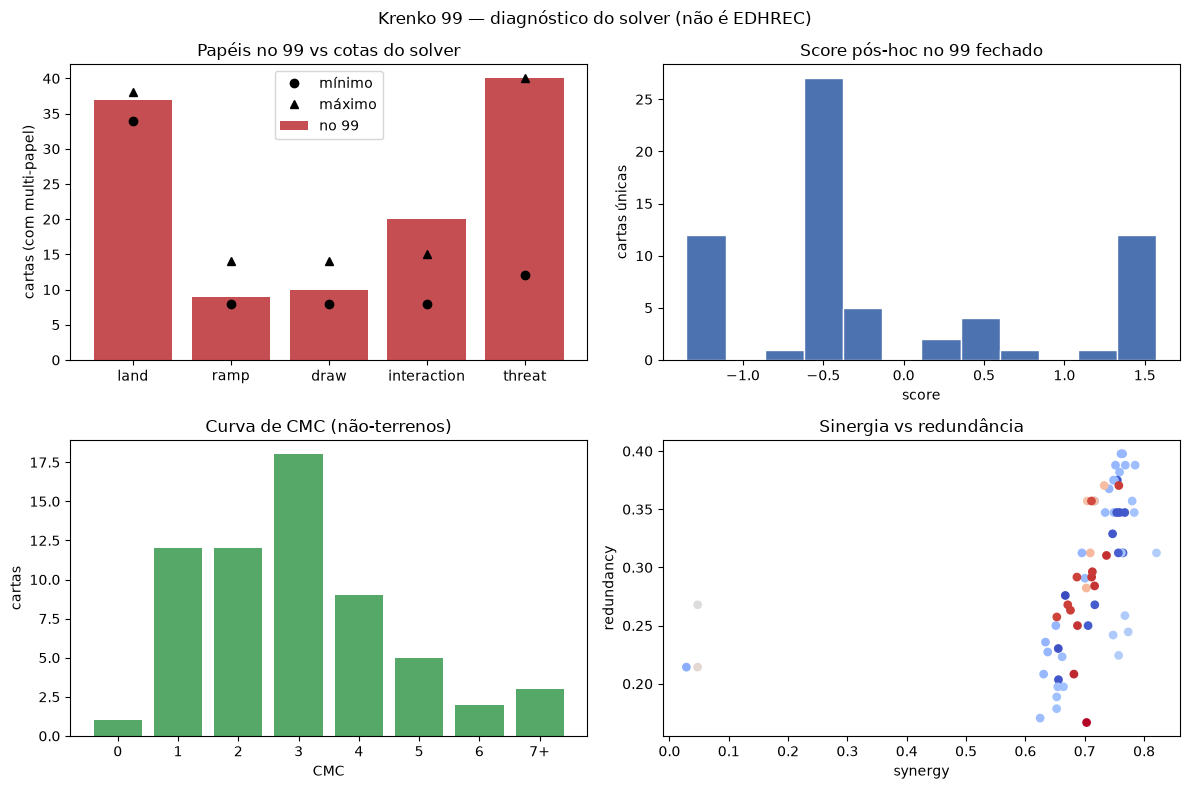

In [26]:
import matplotlib.pyplot as plt

body = analysis[analysis["origin"] != "commander"].copy()
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

qplot = quota_df[quota_df["role"] != "other"]
axes[0, 0].bar(qplot["role"], qplot["count"], color="#c44e52", label="no 99")
axes[0, 0].plot(qplot["role"], qplot["min"], "ko", label="mínimo")
axes[0, 0].plot(qplot["role"], qplot["max"], "k^", label="máximo")
axes[0, 0].set_title("Papéis no 99 vs cotas do solver")
axes[0, 0].set_ylabel("cartas (com multi-papel)")
axes[0, 0].legend()

axes[0, 1].hist(body["total"], bins=12, color="#4c72b0", edgecolor="white")
axes[0, 1].set_title("Score pós-hoc no 99 fechado")
axes[0, 1].set_xlabel("score")
axes[0, 1].set_ylabel("cartas únicas")

curve = validation.get("curve") or {}
order = ["0", "1", "2", "3", "4", "5", "6", "7+"]
axes[1, 0].bar(order, [curve.get(k, 0) for k in order], color="#55a868")
axes[1, 0].set_title("Curva de CMC (não-terrenos)")
axes[1, 0].set_xlabel("CMC")
axes[1, 0].set_ylabel("cartas")

axes[1, 1].scatter(body["synergy"], body["redundancy"], c=body["total"], cmap="coolwarm", s=28)
axes[1, 1].set_title("Sinergia vs redundância")
axes[1, 1].set_xlabel("synergy")
axes[1, 1].set_ylabel("redundancy")

fig.suptitle("Krenko 99 — diagnóstico do solver (não é EDHREC)")
fig.tight_layout()
plt.show()

## Extremos: o que o greedy mais “quis” vs o que só ocupou slot

No 99 fechado, scores altos ainda carregam overlap com goblin/token/damage. Scores baixos são seed (Mountain), artefactos genéricos puxados por queries de ramp/draw, ou cartas cujo papel já estava cheio.

In [27]:
ranked = body.sort_values("total", ascending=False)
print("Top 12 (melhor score pós-hoc)")
display(ranked.head(12)[["quantity", "name", "roles", "total", "synergy", "chroma_query", "insert_rank"]])
print("Bottom 12 (pior score pós-hoc — candidatas naturais a cut)")
display(ranked.tail(12)[["quantity", "name", "roles", "total", "synergy", "redundancy_with", "origin"]])

Top 12 (melhor score pós-hoc)


,quantity,name,roles,total,synergy,chroma_query,insert_rank
8,1,Brightstone Ritual,ramp,1.5729,0.7031,"{T}: Create X 1/1 red Goblin creature tokens, where X is the number of Goblins you control.",19.0
3,1,Aladdin's Lamp,draw,1.4718,0.6817,draw a card,26.0
56,1,Power Depot,land,1.4387,0.7366,add mana ramp artifact,44.0
18,1,Geosurge,ramp,1.4356,0.7166,add mana ramp artifact,28.0
12,1,Dangerous Wager,draw,1.4254,0.6877,draw a card,6.0
41,1,Illuminated Folio,draw,1.4149,0.7116,draw a card,29.0
65,1,Wizard's Rockets,draw,1.4107,0.7128,add mana ramp artifact,10.0
60,1,Salvaged Manaworker,"ramp, threat",1.3962,0.7574,add mana ramp artifact,5.0
7,1,Book of Rass,draw,1.3834,0.6759,draw a card,20.0
5,1,Blasted Landscape,"draw, land",1.3678,0.6714,draw a card,56.0


Bottom 12 (pior score pós-hoc — candidatas naturais a cut)


,quantity,name,roles,total,synergy,redundancy_with,origin
19,1,Goblin Artillery,"interaction, threat",-1.2086,0.7645,Goblin Brawler,fill greedy
43,1,Krenko's Enforcer,threat,-1.2244,0.7566,Goblin Brawler,fill greedy
28,1,Goblin Lyre,interaction,-1.2388,0.7056,Goblin Chainwhirler,fill greedy
58,1,Relic Robber,"interaction, threat",-1.2412,0.7169,Howlsquad Heavy,fill greedy
20,1,Goblin Brawler,threat,-1.2513,0.7674,Goblin Spelunkers,fill greedy
22,1,Goblin Chainwhirler,"interaction, threat",-1.2667,0.7469,Goblin Brawler,fill greedy
23,1,Goblin Chariot,threat,-1.2684,0.7589,Goblin Cohort,fill greedy
42,1,Jester's Scepter,interaction,-1.2734,0.6557,Honored Heirloom,fill greedy
33,1,Goblin Spelunkers,threat,-1.2783,0.7539,Goblin Brawler,fill greedy
2,1,Agate Assault,interaction,-1.3115,0.6554,Goblin Goliath,fill greedy


## Ficha de uma carta

Troque o nome para ver oracle, papéis e o texto de escolha.

In [28]:
def show_card(name: str) -> pd.Series:
    hit = analysis[analysis["name"].str.lower() == name.lower()]
    if hit.empty:
        raise KeyError(f"{name!r} não está na lista/commander")
    row = hit.iloc[0]
    print(row["name"], "—", row["type_line"])
    print(row.get("mana_cost") or "", "CMC", row["cmc"], "USD", row.get("price_usd"))
    print("papéis:", row["roles"])
    print("oracle:")
    print(row["oracle_text"] or "(vazio no catálogo — DFC/split sem card_faces no SQLite)")
    print()
    if pd.notna(row.get("insert_rank")):
        print(
            f"POR QUE ENTROU: fill #{int(row['insert_rank'])} com score {row['insert_score']}; "
            f"query Chroma = {row.get('chroma_query')!r} (d={row.get('chroma_distance')})."
        )
        print(
            "O overlap de palavras NÃO significa que a carta cria fichas. "
            "'goblin tokens damage' é a query de texto; Jaccard parte palavras, inclusive 'creature' no type line."
        )
    print()
    print(row["why"])
    return row

show_card("Kumano Faces Kakkazan // Etching of Kumano")

Kumano Faces Kakkazan // Etching of Kumano — Enchantment — Saga // Enchantment Creature — Human Shaman
{R} CMC 1.0 USD 0.22
papéis: interaction, threat
oracle:
(As this Saga enters and after your draw step, add a lore counter.)
I — This Saga deals 1 damage to each opponent and each planeswalker they control.
II — When you next cast a creature spell this turn, that creature enters with an additional +1/+1 counter on it.
III — Exile this Saga, then return it to the battlefield transformed under your control.

Haste
If a creature dealt damage this turn by a source you controlled would die, exile it instead.

POR QUE ENTROU: fill #62 com score 1.3431; query Chroma = 'Krenko, Mob Boss' (d=0.5778).
O overlap de palavras NÃO significa que a carta cria fichas. 'goblin tokens damage' é a query de texto; Jaccard parte palavras, inclusive 'creature' no type line.

Entrou no fill porque o Chroma a devolveu na busca «Krenko, Mob Boss» (distância 0.578 → sinergia geométrica 0.634). Ordem de inserção

name                                                                                                                                                                                                                                                                                                                                                                                    Kumano Faces Kakkazan // Etching of Kumano
type_line                                                                                                                                                                                                                                                                                                                                                                Enchantment — Saga // Enchantment Creature — Human Shaman
oracle_text        (As this Saga enters and after your draw step, add a lore counter.)\nI — This Saga deals 1 damage to each opponent and each planeswalker they c